# Importation

In [42]:
#!pip install xgboost lightgbm -q

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_validate, StratifiedGroupKFold, RandomizedSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [7]:
df = pd.read_csv(r"C:\PhiUSIIL_Phishing_URL_Dataset.csv", encoding="latin1")

# EDA

In [ ]:
df.shape

In [ ]:
df.info()

In [8]:
# copie de sécurité
df_check = df.copy()

# nettoyer les noms de colonnes
df_check.columns = df_check.columns.str.replace("ï»¿", "", regex=False).str.strip()

print("Shape initial :", df_check.shape)
print("\nColonnes :")
print(df_check.columns.tolist())

Shape initial : (235795, 56)

Colonnes :
['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


label
0    100945
1    134850
Name: count, dtype: int64


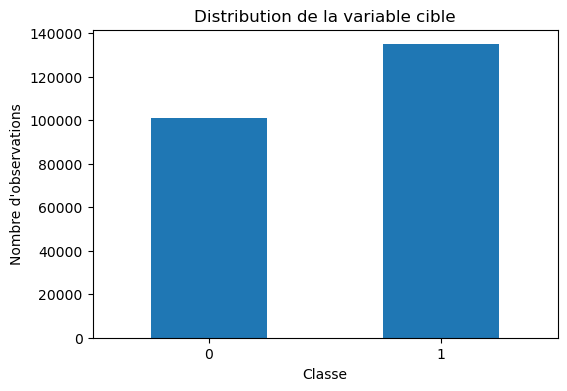

In [9]:
label_counts = df["label"].value_counts().sort_index()
print(label_counts)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Distribution de la variable cible")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.show()

In [10]:
label_percent = df["label"].value_counts(normalize=True).sort_index() * 100
print(label_percent)

label
0    42.810492
1    57.189508
Name: proportion, dtype: float64


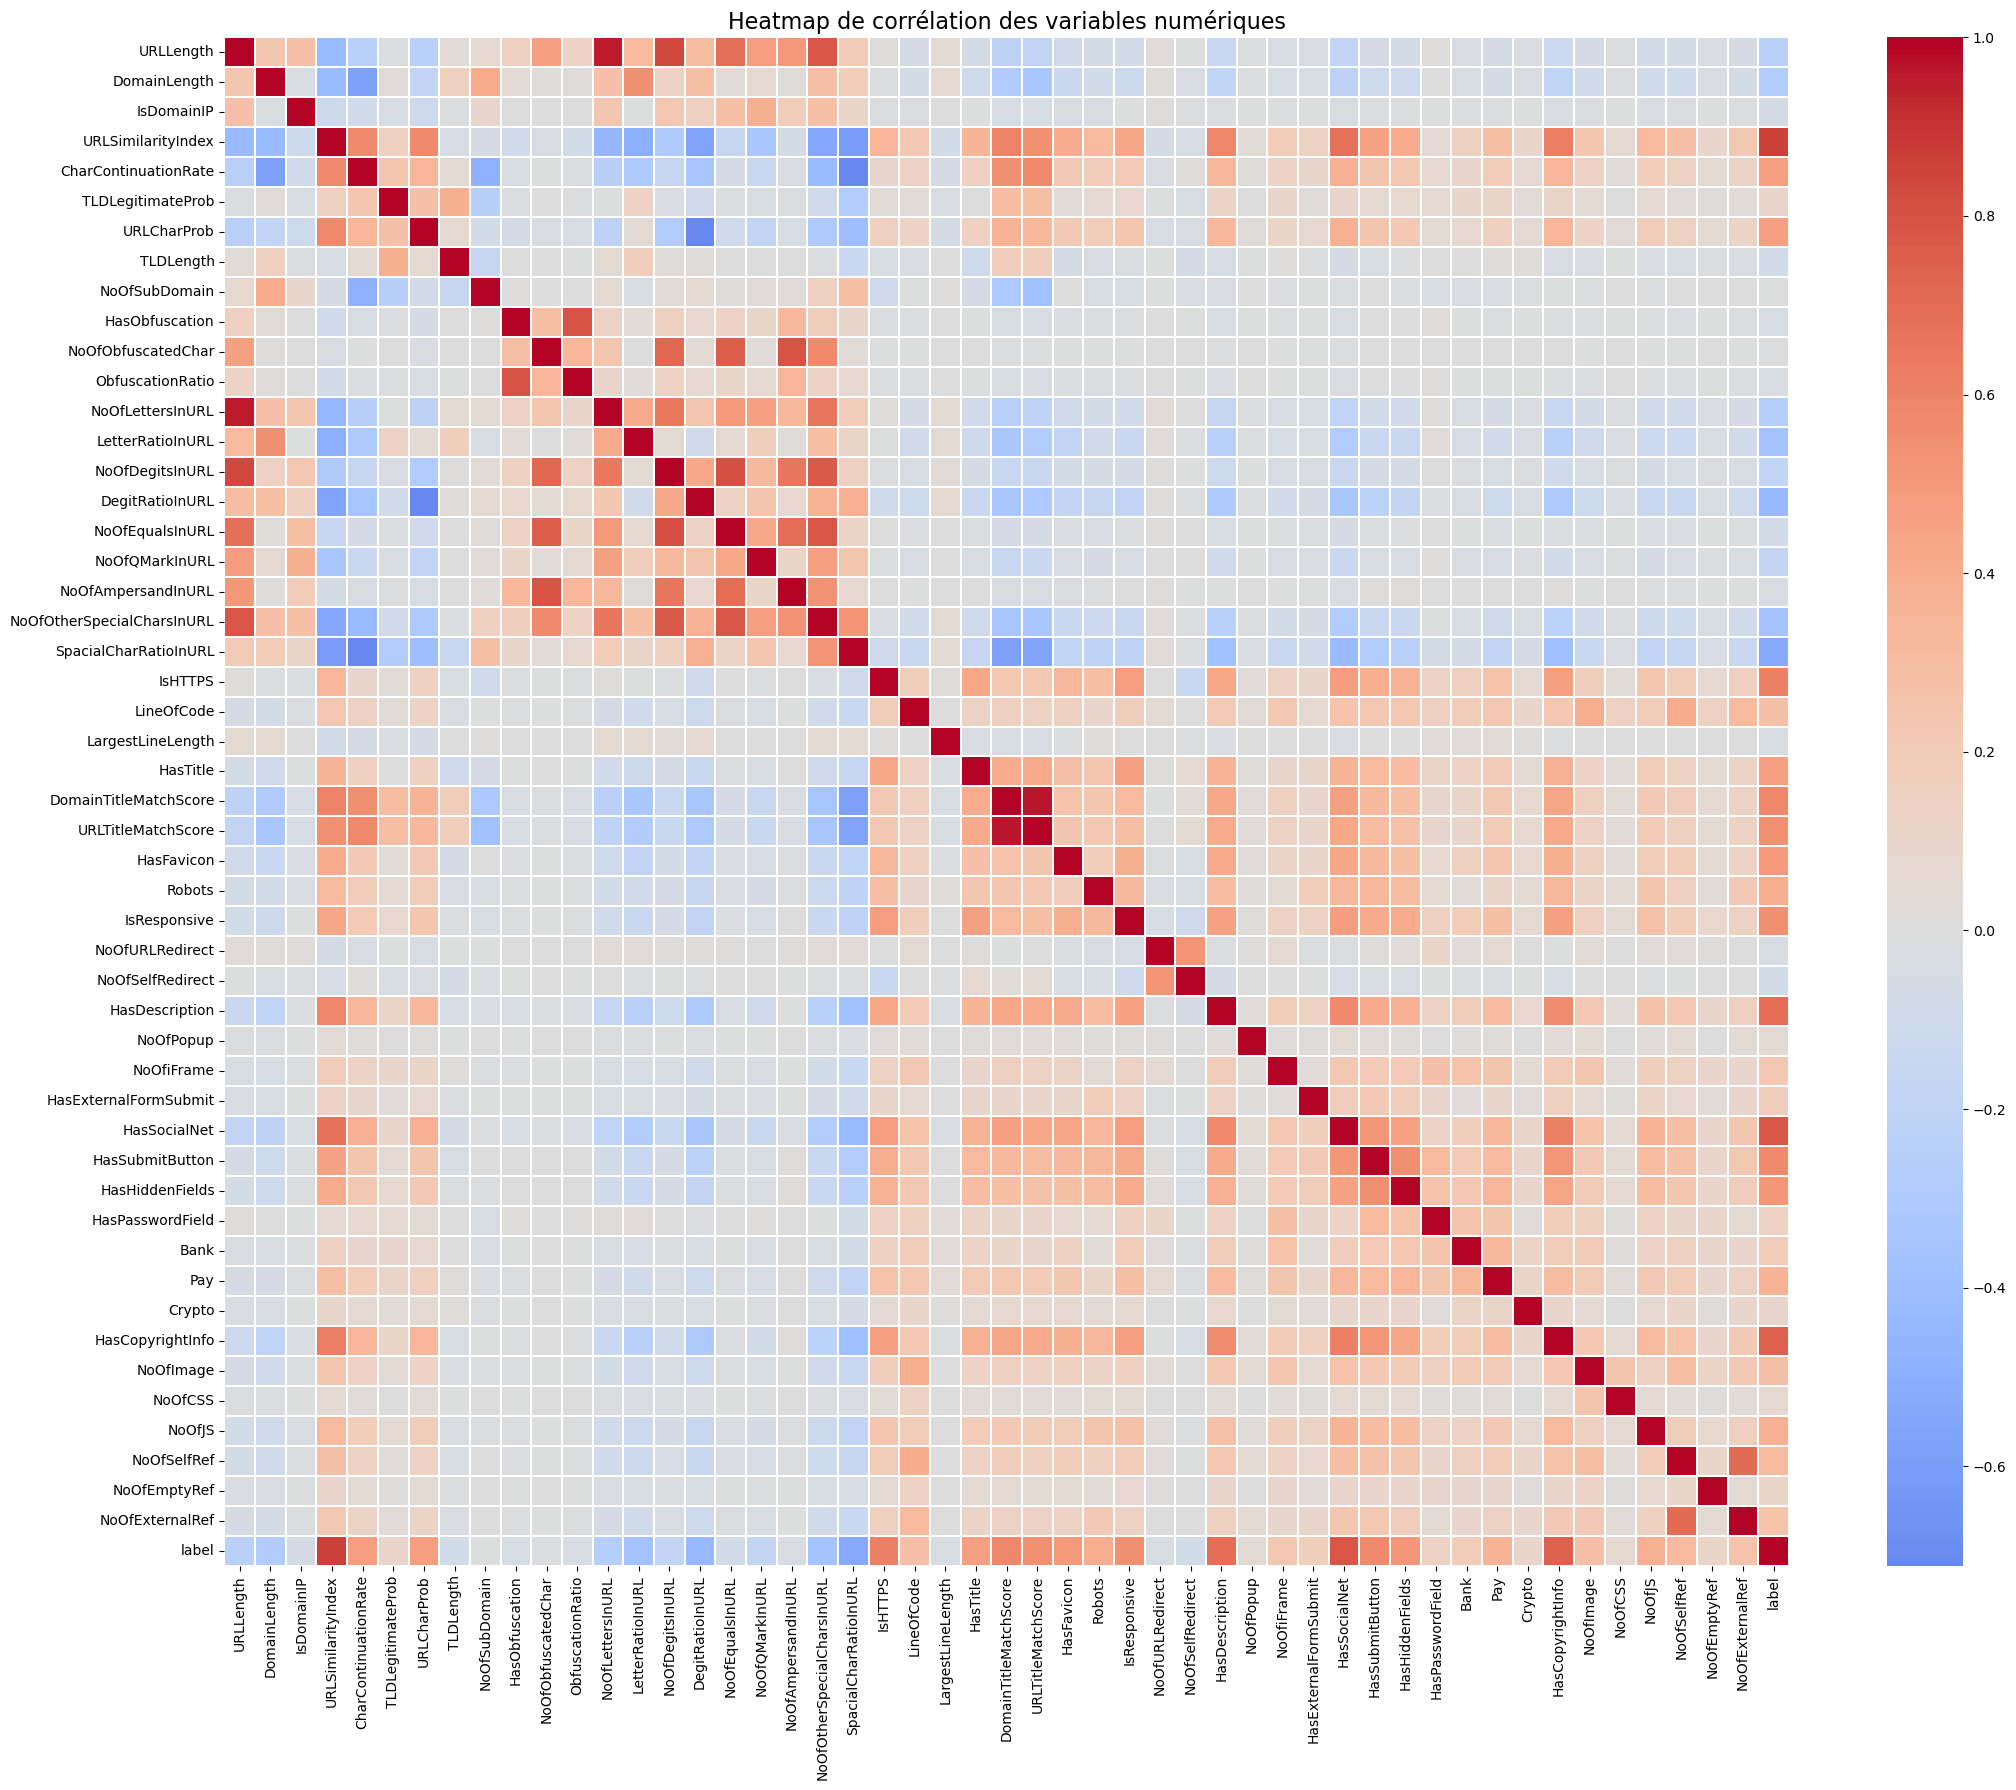

In [11]:
# garder seulement les colonnes numériques
df_num = df.select_dtypes(include=[np.number])

# matrice de corrélation
corr_matrix = df_num.corr()

# afficher le heatmap
plt.figure(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=False,
    linewidths=0.3
)
plt.title("Heatmap de corrélation des variables numériques", fontsize=16)
plt.tight_layout()
plt.show()

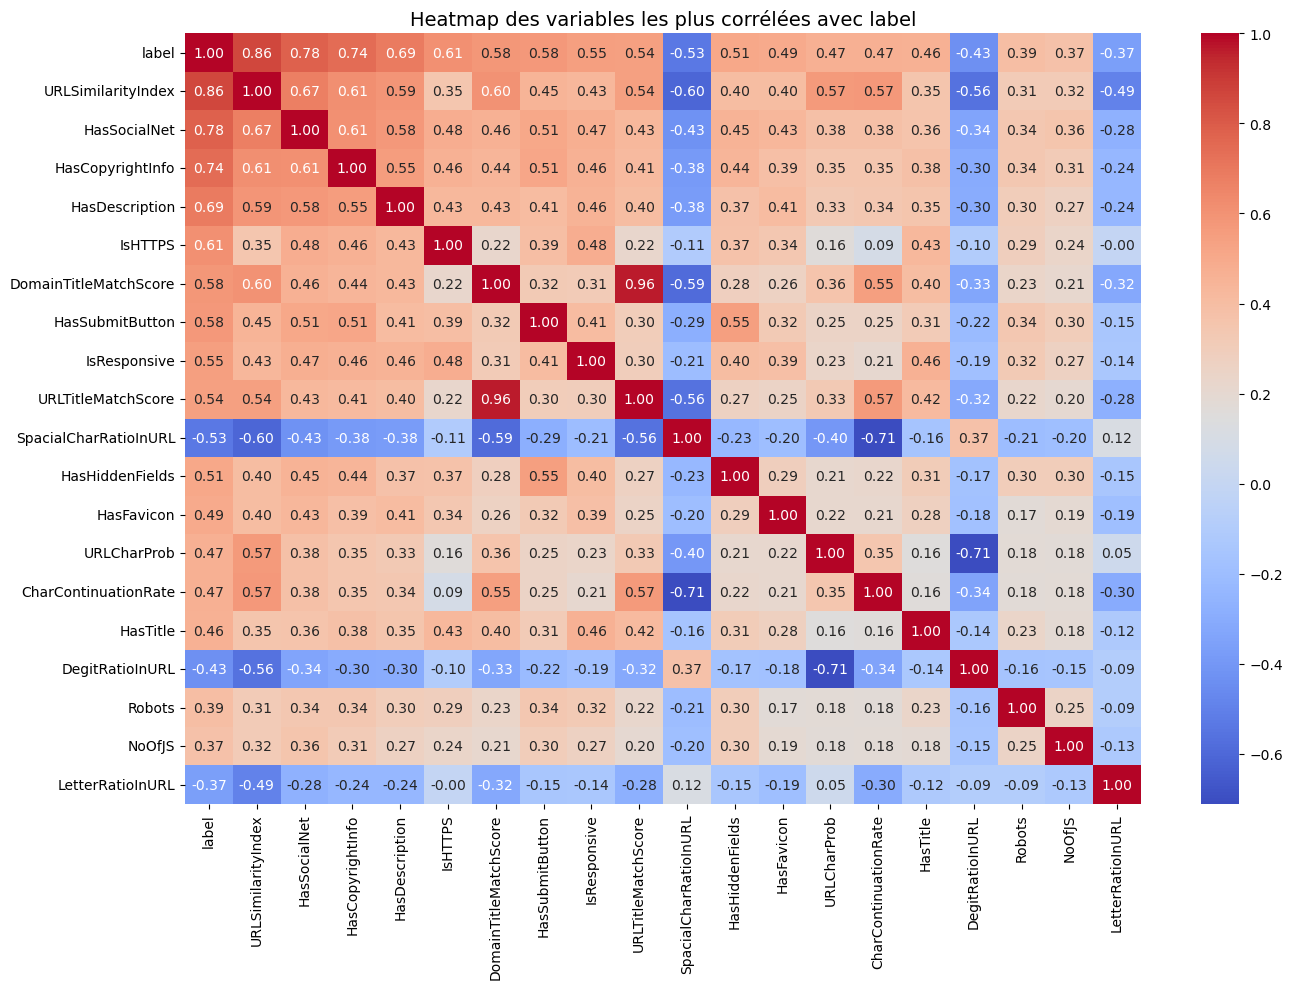

In [12]:
df_num = df.select_dtypes(include=["number"])

top_corr = df_num.corr()["label"].abs().sort_values(ascending=False).head(20).index
corr_top = df_num[top_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_top, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap des variables les plus corrélées avec label", fontsize=14)
plt.tight_layout()
plt.show()

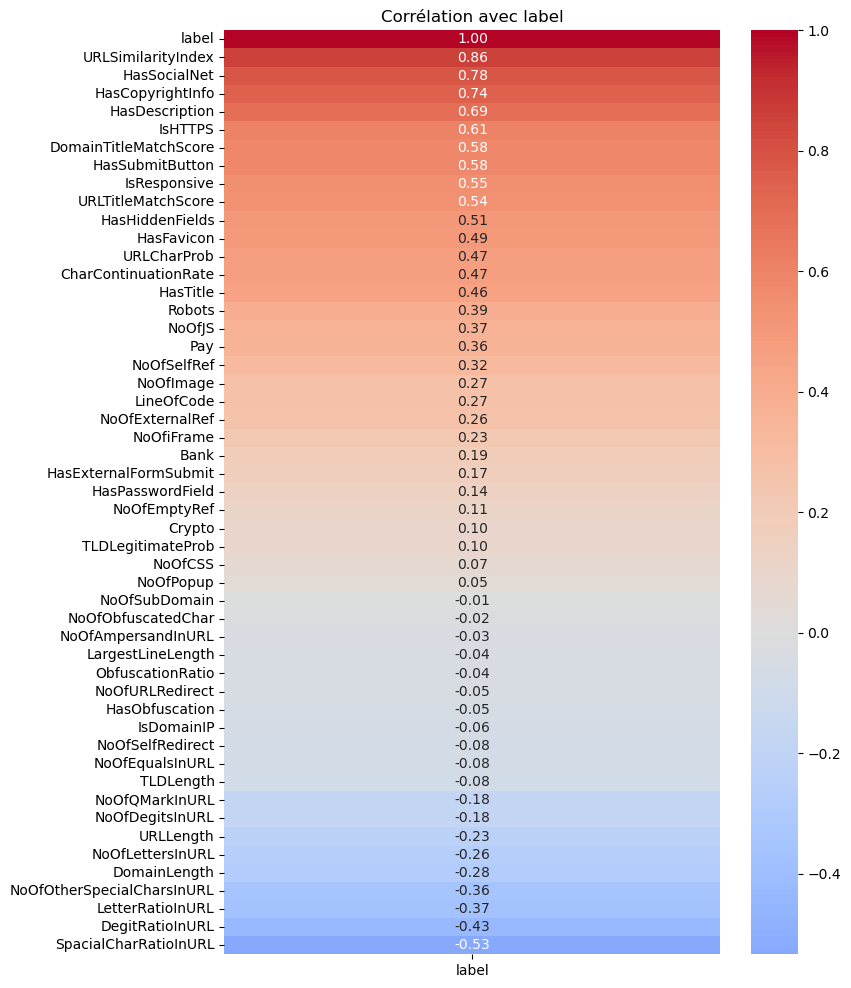

In [15]:
# Corrélation avec label
corr_label = df[num_cols].corr()["label"].sort_values(ascending=False)
plt.figure(figsize=(8, 12))
sns.heatmap(corr_label.to_frame(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélation avec label")
plt.show()

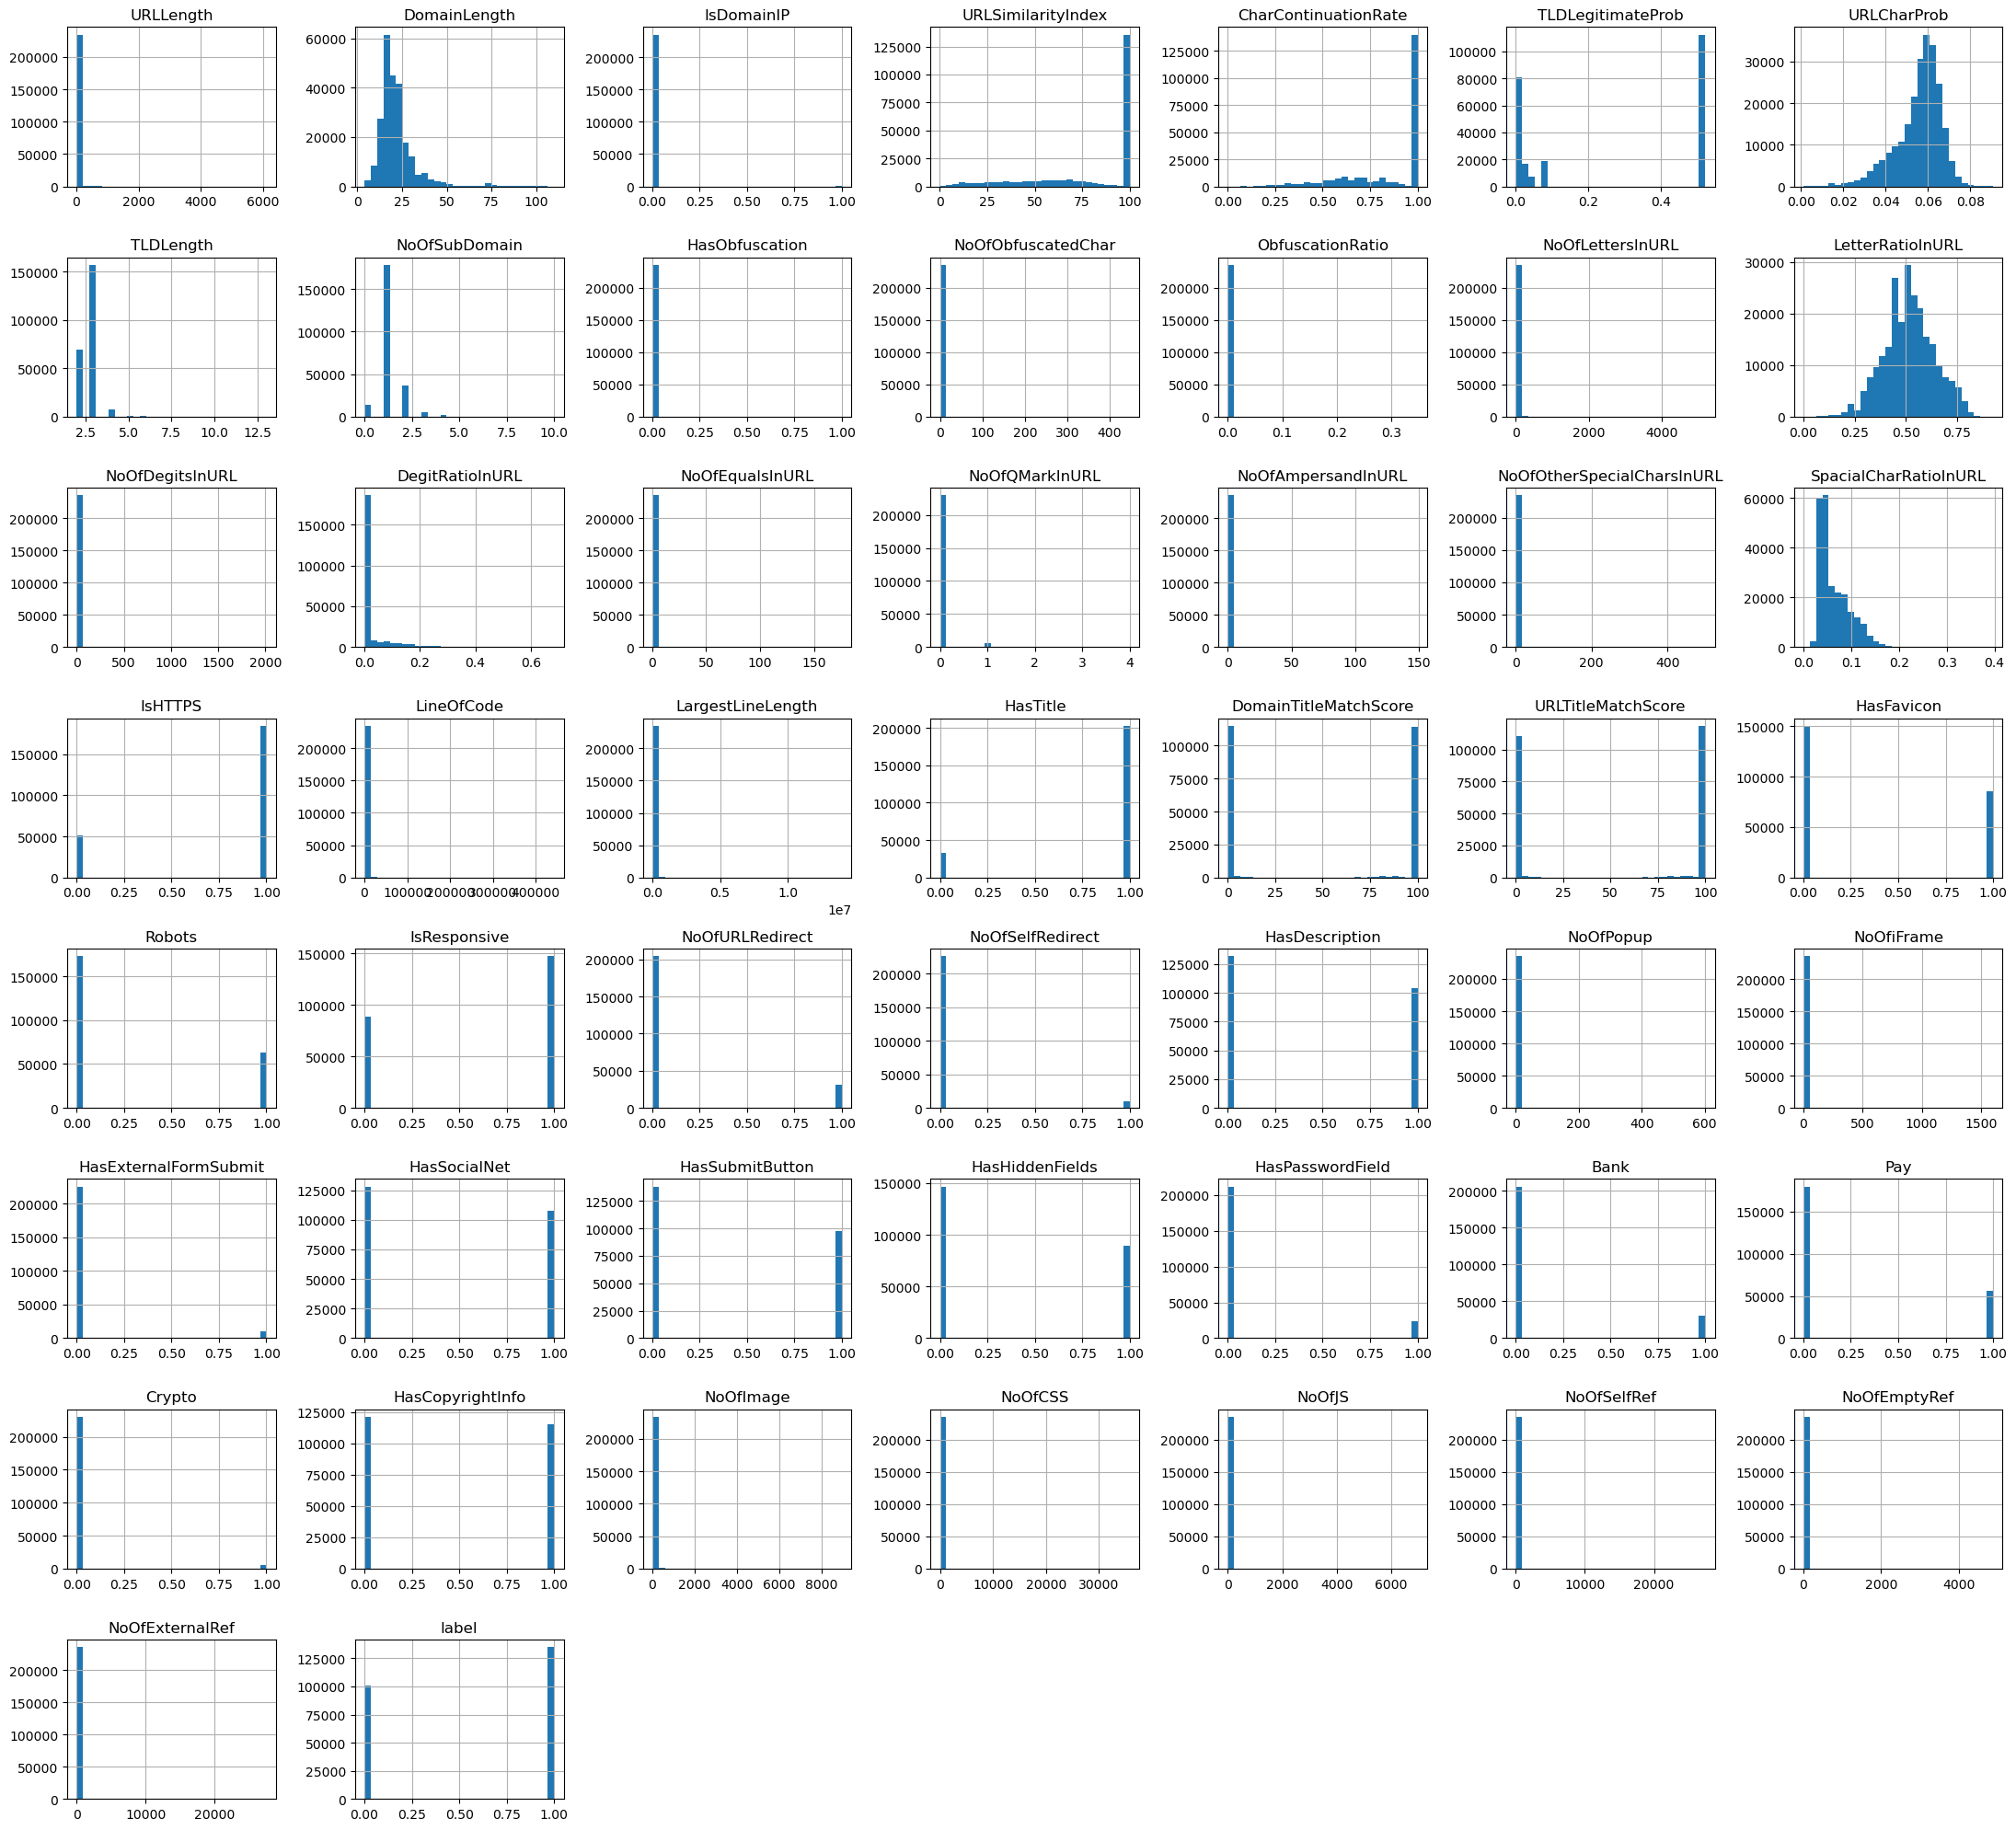

In [16]:
# Histogrammes
df[num_cols].hist(figsize=(22, 20), bins=30)
plt.tight_layout()
plt.show()

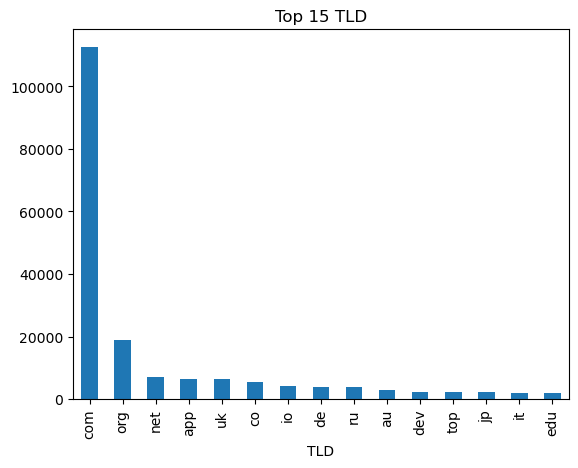

In [17]:
# TLD fréquents
df["TLD"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 TLD")
plt.show()

In [4]:
TARGET_COL = "label"

TEXT_COLS = ["FILENAME", "URL", "Domain", "Title"]
BASE_DROP_COLS = TEXT_COLS + [TARGET_COL]

SUSPECT_COLS = [
    "URLSimilarityIndex",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "TLDLegitimateProb",
    "URLCharProb",
    "CharContinuationRate"
]

In [5]:
exact_duplicates = df_check.duplicated().sum()
print("Nombre de doublons exacts :", exact_duplicates)

Nombre de doublons exacts : 0


In [6]:
feature_cols_all = [col for col in df_check.columns if col != TARGET_COL]
feature_duplicates = df_check[feature_cols_all].duplicated().sum()
print("Nombre de doublons de features :", feature_duplicates)

Nombre de doublons de features : 0


In [7]:
df_nodup = df_check.drop_duplicates().reset_index(drop=True)

print("Avant suppression :", df_check.shape)
print("Après suppression :", df_nodup.shape)

Avant suppression : (235795, 56)
Après suppression : (235795, 56)


# Modélisation

In [8]:
def build_models(X_df):
    num_cols = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X_df.select_dtypes(include=["object"]).columns.tolist()

    linear_preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    tree_preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    models = {
        "Logistic Regression L2": Pipeline(steps=[
            ("preprocessor", linear_preprocessor),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=3000,
                random_state=42
            ))
        ]),

        "Decision Tree": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DecisionTreeClassifier(
                max_depth=10,
                random_state=42
            ))
        ]),

        "Random Forest": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "XGBoost": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "LightGBM": Pipeline(steps=[
            ("preprocessor", tree_preprocessor),
            ("model", LGBMClassifier(
                n_estimators=200,
                learning_rate=0.1,
                random_state=42
            ))
        ])
    }

    return models

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

In [10]:
def run_experiment(X_train, X_test, y_train, y_test, experiment_name):
    models = build_models(X_train)
    results = []

    print(f"\n===== {experiment_name} =====")

    for name, model in models.items():
        print(f"Entraînement : {name}")
        res = evaluate_model(model, X_train, X_test, y_train, y_test, name)
        results.append(res)

    results_df = pd.DataFrame(results)
    results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC", "Confusion Matrix"]]
    results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

    return results_df

# SC1 Split aléatoire

In [25]:
# X et y
X_case1 = df_nodup.drop(columns=BASE_DROP_COLS, errors="ignore")
y_case1 = df_nodup[TARGET_COL]

# split aléatoire
X_train_case1, X_test_case1, y_train_case1, y_test_case1 = train_test_split(
    X_case1,
    y_case1,
    test_size=0.2,
    random_state=42,
    stratify=y_case1
)

print("Train shape :", X_train_case1.shape)
print("Test shape  :", X_test_case1.shape)

results_case1 = run_experiment(
    X_train_case1, X_test_case1, y_train_case1, y_test_case1,
    "CAS 1 - Random Split après suppression des doublons"
)

results_case1

Train shape : (188636, 51)
Test shape  : (47159, 51)

===== CAS 1 - Random Split après suppression des doublons =====
Entraînement : Logistic Regression L2
Entraînement : Decision Tree
Entraînement : Random Forest
Entraînement : XGBoost
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107880, number of negative: 80756
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5254
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 237
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571895 -> initscore=0.289587
[LightGBM] [Info] Start training from score 0.289587
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Confusion Matrix
0,Decision Tree,1.000000,1.000000,1.0,1.000000,1.0,1.0,"[[20189, 0], [0, 26970]]"
1,LightGBM,1.000000,1.000000,1.0,1.000000,1.0,1.0,"[[20189, 0], [0, 26970]]"
2,XGBoost,1.000000,1.000000,1.0,1.000000,1.0,1.0,"[[20189, 0], [0, 26970]]"
3,Random Forest,0.999979,0.999963,1.0,0.999981,1.0,1.0,"[[20188, 1], [0, 26970]]"
4,Logistic Regression L2,0.999873,0.999778,1.0,0.999889,1.0,1.0,"[[20183, 6], [0, 26970]]"


# SC2 Split par Domain

In [22]:
# X, y et groupes
X_case2 = df_nodup.drop(columns=BASE_DROP_COLS, errors="ignore")
y_case2 = df_nodup[TARGET_COL]
groups_case2 = df_nodup["Domain"]

# split par domaine
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_case2, y_case2, groups=groups_case2))

X_train_case2 = X_case2.iloc[train_idx]
X_test_case2  = X_case2.iloc[test_idx]
y_train_case2 = y_case2.iloc[train_idx]
y_test_case2  = y_case2.iloc[test_idx]

# vérification
train_domains = set(groups_case2.iloc[train_idx])
test_domains = set(groups_case2.iloc[test_idx])

print("Train shape :", X_train_case2.shape)
print("Test shape  :", X_test_case2.shape)
print("Nombre de domaines communs :", len(train_domains & test_domains))

results_case2 = run_experiment(
    X_train_case2, X_test_case2, y_train_case2, y_test_case2,
    "CAS 2 - Group Split par Domain"
)

results_case2

Train shape : (189074, 51)
Test shape  : (46721, 51)
Nombre de domaines communs : 0

===== CAS 2 - Group Split par Domain =====
Entraînement : Logistic Regression L2
Entraînement : Decision Tree
Entraînement : Random Forest
Entraînement : XGBoost
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107927, number of negative: 81147
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5248
[LightGBM] [Info] Number of data points in the train set: 189074, number of used features: 238
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.570819 -> initscore=0.285193
[LightGBM] [Info] Start training from score 0.285193
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Confusion Matrix
0,Decision Tree,0.999957,0.999926,1.0,0.999963,0.999949,0.999926,"[[19796, 2], [0, 26923]]"
1,XGBoost,0.999957,0.999926,1.0,0.999963,1.000000,1.000000,"[[19796, 2], [0, 26923]]"
2,Random Forest,0.999957,0.999926,1.0,0.999963,1.000000,1.000000,"[[19796, 2], [0, 26923]]"
3,LightGBM,0.999957,0.999926,1.0,0.999963,1.000000,1.000000,"[[19796, 2], [0, 26923]]"
4,Logistic Regression L2,0.999893,0.999814,1.0,0.999907,0.999997,0.999998,"[[19793, 5], [0, 26923]]"


# SC3 Sans les features très fortes

In [23]:
# construire X réduit
X_case3 = df_nodup.drop(columns=BASE_DROP_COLS + SUSPECT_COLS, errors="ignore")
y_case3 = df_nodup[TARGET_COL]

# split aléatoire
X_train_case3, X_test_case3, y_train_case3, y_test_case3 = train_test_split(
    X_case3,
    y_case3,
    test_size=0.2,
    random_state=42,
    stratify=y_case3
)

print("Train shape :", X_train_case3.shape)
print("Test shape  :", X_test_case3.shape)
print("Colonnes supprimées :", SUSPECT_COLS)

results_case3 = run_experiment(
    X_train_case3, X_test_case3, y_train_case3, y_test_case3,
    "CAS 3 - Sans les features très fortes"
)

results_case3

Train shape : (188636, 45)
Test shape  : (47159, 45)
Colonnes supprimées : ['URLSimilarityIndex', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'TLDLegitimateProb', 'URLCharProb', 'CharContinuationRate']

===== CAS 3 - Sans les features très fortes =====
Entraînement : Logistic Regression L2
Entraînement : Decision Tree
Entraînement : Random Forest
Entraînement : XGBoost
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107880, number of negative: 80756
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044772 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4087
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 231
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571895 -> initscore=0.289587
[LightGBM] [Info] Start training from score 0.289587
[LightGBM] [Warning] No further splits wit

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Confusion Matrix
0,LightGBM,0.999958,0.999926,1.000000,0.999963,1.000000,1.000000,"[[20187, 2], [0, 26970]]"
1,XGBoost,0.999936,0.999926,0.999963,0.999944,1.000000,1.000000,"[[20187, 2], [1, 26969]]"
2,Random Forest,0.999788,0.999629,1.000000,0.999815,1.000000,1.000000,"[[20179, 10], [0, 26970]]"
3,Logistic Regression L2,0.999343,0.999259,0.999592,0.999425,0.999994,0.999996,"[[20169, 20], [11, 26959]]"
4,Decision Tree,0.998749,0.999073,0.998739,0.998906,0.998955,0.998699,"[[20164, 25], [34, 26936]]"


# SC4 split par Domain & features fortes retirées

In [24]:
X_case4 = df_nodup.drop(columns=BASE_DROP_COLS + SUSPECT_COLS, errors="ignore")
y_case4 = df_nodup[TARGET_COL]
groups_case4 = df_nodup["Domain"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_case4, y_case4, groups=groups_case4))

X_train_case4 = X_case4.iloc[train_idx]
X_test_case4  = X_case4.iloc[test_idx]
y_train_case4 = y_case4.iloc[train_idx]
y_test_case4  = y_case4.iloc[test_idx]

train_domains = set(groups_case4.iloc[train_idx])
test_domains = set(groups_case4.iloc[test_idx])

print("Train shape :", X_train_case4.shape)
print("Test shape  :", X_test_case4.shape)
print("Nombre de domaines communs :", len(train_domains & test_domains))

results_case4 = run_experiment(
    X_train_case4, X_test_case4, y_train_case4, y_test_case4,
    "CAS 4 - Test strict"
)

results_case4

Train shape : (189074, 45)
Test shape  : (46721, 45)
Nombre de domaines communs : 0

===== CAS 4 - Test strict =====
Entraînement : Logistic Regression L2
Entraînement : Decision Tree
Entraînement : Random Forest
Entraînement : XGBoost
Entraînement : LightGBM
[LightGBM] [Info] Number of positive: 107927, number of negative: 81147
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4081
[LightGBM] [Info] Number of data points in the train set: 189074, number of used features: 232
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.570819 -> initscore=0.285193
[LightGBM] [Info] Start training from score 0.285193
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Confusion Matrix
0,LightGBM,0.999936,0.999889,1.000000,0.999944,1.000000,1.000000,"[[19795, 3], [0, 26923]]"
1,XGBoost,0.999936,0.999926,0.999963,0.999944,1.000000,1.000000,"[[19796, 2], [1, 26922]]"
2,Random Forest,0.999829,0.999703,1.000000,0.999851,0.999999,0.999999,"[[19790, 8], [0, 26923]]"
3,Logistic Regression L2,0.999358,0.999146,0.999740,0.999443,0.999973,0.999974,"[[19775, 23], [7, 26916]]"
4,Decision Tree,0.998759,0.998960,0.998886,0.998923,0.998976,0.998438,"[[19770, 28], [30, 26893]]"


# Comparaison finale des 4 cas

In [27]:
results_case1["Scenario"] = "Case 1 - Random Split"
results_case2["Scenario"] = "Case 2 - Group Split"
results_case3["Scenario"] = "Case 3 - No Strong Features"
results_case4["Scenario"] = "Case 4 - Strict Test"

comparison_df = pd.concat(
    [results_case1, results_case2, results_case3, results_case4],
    ignore_index=True
)

comparison_df = comparison_df[
    ["Scenario", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
]

comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Scenario,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Case 1 - Random Split,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Case 1 - Random Split,LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Case 1 - Random Split,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,Case 1 - Random Split,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,Case 1 - Random Split,Logistic Regression L2,0.9999,0.9998,1.0000,0.9999,1.0000,1.0000
5,Case 2 - Group Split,Decision Tree,1.0000,0.9999,1.0000,1.0000,0.9999,0.9999
6,Case 2 - Group Split,XGBoost,1.0000,0.9999,1.0000,1.0000,1.0000,1.0000
7,Case 2 - Group Split,Random Forest,1.0000,0.9999,1.0000,1.0000,1.0000,1.0000
8,Case 2 - Group Split,LightGBM,1.0000,0.9999,1.0000,1.0000,1.0000,1.0000
9,Case 2 - Group Split,Logistic Regression L2,0.9999,0.9998,1.0000,0.9999,1.0000,1.0000


# cross-validation

In [11]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [30]:
X_cv = df_nodup.drop(columns=BASE_DROP_COLS + SUSPECT_COLS, errors="ignore")
y_cv = df_nodup[TARGET_COL]
groups_cv = df_nodup["Domain"]

print("Shape X_cv :", X_cv.shape)
print("Shape y_cv :", y_cv.shape)
print("Nombre de domaines uniques :", groups_cv.nunique())

Shape X_cv : (235795, 45)
Shape y_cv : (235795,)
Nombre de domaines uniques : 220086


In [31]:
models_cv = build_models(X_cv)
models_cv = {
    "Logistic Regression L2": models_cv["Logistic Regression L2"],
    "Random Forest": models_cv["Random Forest"],
    "XGBoost": models_cv["XGBoost"],
    "LightGBM": models_cv["LightGBM"]
}

list(models_cv.keys())

['Logistic Regression L2', 'Random Forest', 'XGBoost', 'LightGBM']

In [32]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results_list = []

for model_name, model in models_cv.items():
    print(f"Cross-validation en cours : {model_name}")

    scores = cross_validate(
        model,
        X_cv,
        y_cv,
        groups=groups_cv,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_list.append({
        "Model": model_name,
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "Accuracy_std": scores["test_accuracy"].std(),
        "Precision_mean": scores["test_precision"].mean(),
        "Precision_std": scores["test_precision"].std(),
        "Recall_mean": scores["test_recall"].mean(),
        "Recall_std": scores["test_recall"].std(),
        "F1_mean": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(),
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "PR_AUC_mean": scores["test_pr_auc"].mean(),
        "PR_AUC_std": scores["test_pr_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results_list).sort_values(by="F1_mean", ascending=False).reset_index(drop=True)
cv_results_df

Cross-validation en cours : Logistic Regression L2
Cross-validation en cours : Random Forest
Cross-validation en cours : XGBoost
Cross-validation en cours : LightGBM


,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
0,LightGBM,0.999940,0.000044,0.999904,0.000069,0.999993,0.000015,0.999948,0.000038,1.000000,3.765757e-08,1.000000,2.746979e-08
1,XGBoost,0.999928,0.000037,0.999911,0.000050,0.999963,0.000023,0.999937,0.000032,1.000000,1.390872e-07,1.000000,1.022390e-07
2,Random Forest,0.999817,0.000070,0.999696,0.000111,0.999985,0.000018,0.999841,0.000060,0.999999,1.174048e-06,0.999999,9.875439e-07
3,Logistic Regression L2,0.999228,0.000190,0.999022,0.000302,0.999629,0.000071,0.999325,0.000165,0.999980,1.479122e-05,0.999981,1.601963e-05


In [33]:
cv_results_df.style.format({
    "Accuracy_mean": "{:.6f}",
    "Accuracy_std": "{:.6f}",
    "Precision_mean": "{:.6f}",
    "Precision_std": "{:.6f}",
    "Recall_mean": "{:.6f}",
    "Recall_std": "{:.6f}",
    "F1_mean": "{:.6f}",
    "F1_std": "{:.6f}",
    "ROC_AUC_mean": "{:.6f}",
    "ROC_AUC_std": "{:.6f}",
    "PR_AUC_mean": "{:.6f}",
    "PR_AUC_std": "{:.6f}"
})

,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,ROC_AUC_mean,ROC_AUC_std,PR_AUC_mean,PR_AUC_std
0,LightGBM,0.999940,0.000044,0.999904,0.000069,0.999993,0.000015,0.999948,0.000038,1.000000,0.000000,1.000000,0.000000
1,XGBoost,0.999928,0.000037,0.999911,0.000050,0.999963,0.000023,0.999937,0.000032,1.000000,0.000000,1.000000,0.000000
2,Random Forest,0.999817,0.000070,0.999696,0.000111,0.999985,0.000018,0.999841,0.000060,0.999999,0.000001,0.999999,0.000001
3,Logistic Regression L2,0.999228,0.000190,0.999022,0.000302,0.999629,0.000071,0.999325,0.000165,0.999980,0.000015,0.999981,0.000016


In [34]:
for _, row in cv_results_df.iterrows():
    print(f"\n===== {row['Model']} =====")
    print(f"Accuracy : {row['Accuracy_mean']:.6f} ± {row['Accuracy_std']:.6f}")
    print(f"Precision: {row['Precision_mean']:.6f} ± {row['Precision_std']:.6f}")
    print(f"Recall   : {row['Recall_mean']:.6f} ± {row['Recall_std']:.6f}")
    print(f"F1-score : {row['F1_mean']:.6f} ± {row['F1_std']:.6f}")
    print(f"ROC-AUC  : {row['ROC_AUC_mean']:.6f} ± {row['ROC_AUC_std']:.6f}")
    print(f"PR-AUC   : {row['PR_AUC_mean']:.6f} ± {row['PR_AUC_std']:.6f}")

best_model_cv = cv_results_df.iloc[0]["Model"]
print("\nMeilleur modèle selon F1 moyen en cross-validation :", best_model_cv)


===== LightGBM =====
Accuracy : 0.999940 ± 0.000044
Precision: 0.999904 ± 0.000069
Recall   : 0.999993 ± 0.000015
F1-score : 0.999948 ± 0.000038
ROC-AUC  : 1.000000 ± 0.000000
PR-AUC   : 1.000000 ± 0.000000

===== XGBoost =====
Accuracy : 0.999928 ± 0.000037
Precision: 0.999911 ± 0.000050
Recall   : 0.999963 ± 0.000023
F1-score : 0.999937 ± 0.000032
ROC-AUC  : 1.000000 ± 0.000000
PR-AUC   : 1.000000 ± 0.000000

===== Random Forest =====
Accuracy : 0.999817 ± 0.000070
Precision: 0.999696 ± 0.000111
Recall   : 0.999985 ± 0.000018
F1-score : 0.999841 ± 0.000060
ROC-AUC  : 0.999999 ± 0.000001
PR-AUC   : 0.999999 ± 0.000001

===== Logistic Regression L2 =====
Accuracy : 0.999228 ± 0.000190
Precision: 0.999022 ± 0.000302
Recall   : 0.999629 ± 0.000071
F1-score : 0.999325 ± 0.000165
ROC-AUC  : 0.999980 ± 0.000015
PR-AUC   : 0.999981 ± 0.000016

Meilleur modèle selon F1 moyen en cross-validation : LightGBM


# Best Model

In [12]:
X_case4 = df_nodup.drop(columns=BASE_DROP_COLS + SUSPECT_COLS, errors="ignore")
y_case4 = df_nodup[TARGET_COL]
groups_case4 = df_nodup["Domain"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_case4, y_case4, groups=groups_case4))

X_train_case4 = X_case4.iloc[train_idx]
X_test_case4  = X_case4.iloc[test_idx]
y_train_case4 = y_case4.iloc[train_idx]
y_test_case4  = y_case4.iloc[test_idx]

models_case4 = build_models(X_train_case4)
final_model = models_case4["LightGBM"]

final_model.fit(X_train_case4, y_train_case4)

[LightGBM] [Info] Number of positive: 107927, number of negative: 81147
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035006 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4081
[LightGBM] [Info] Number of data points in the train set: 189074, number of used features: 232
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.570819 -> initscore=0.285193
[LightGBM] [Info] Start training from score 0.285193
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['URLLength', 'DomainLength',
                                                   'IsDomainIP', 'TLDLength',
                                                   'NoOfSubDomain',
                                                   'HasObfuscation',
                                                   'NoOfObfuscatedChar',
                                                   'ObfuscationRatio',
                                                   'NoOfLettersInURL',
                                                   'LetterRatioInURL',
                                                   'NoOfDegitsInURL',
                                                   'DegitRatioInURL',
                                                   'NoOfEqualsInURL',
                                                   'NoOfQMarkInURL',
                                                   'NoOfAmpersandInURL',
                                                   'NoOfOthe...sInURL',
                                                   'SpacialCharRatioInURL',
                                                   'IsHTTPS', 'LineOfCode',
                                                   'LargestLineLength',
                                                   'HasTitle', 'HasFavicon',
                                                   'Robots', 'IsResponsive',
                                                   'NoOfURLRedirect',
                                                   'NoOfSelfRedirect',
                                                   'HasDescription',
                                                   'NoOfPopup', 'NoOfiFrame',
                                                   'HasExternalFormSubmit', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['TLD'])])),
                ('model', LGBMClassifier(n_estimators=200, random_state=42))])

In [13]:
# prédictions
y_pred = final_model.predict(X_test_case4)
y_prob = final_model.predict_proba(X_test_case4)[:, 1]

# métriques
print("===== Evaluation finale sur le test strict =====")
print("Accuracy :", accuracy_score(y_test_case4, y_pred))
print("Precision:", precision_score(y_test_case4, y_pred))
print("Recall   :", recall_score(y_test_case4, y_pred))
print("F1-score :", f1_score(y_test_case4, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test_case4, y_prob))
print("PR-AUC   :", average_precision_score(y_test_case4, y_prob))

print("\n===== Classification Report =====")
print(classification_report(y_test_case4, y_pred))

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== Evaluation finale sur le test strict =====
Accuracy : 0.9999357890456112
Precision: 0.9998885835252173
Recall   : 1.0
F1-score : 0.9999442886590281
ROC-AUC  : 0.9999999587258718
PR-AUC   : 0.9999999696450133

===== Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19798
           1       1.00      1.00      1.00     26923

    accuracy                           1.00     46721
   macro avg       1.00      1.00      1.00     46721
weighted avg       1.00      1.00      1.00     46721



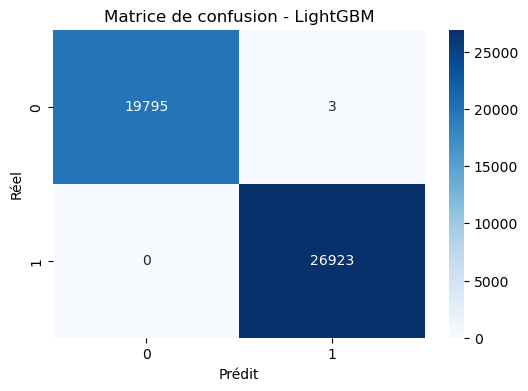

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_case4, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - LightGBM")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [15]:
# récupérer le modèle et le préprocesseur depuis le pipeline
lgbm_model = final_model.named_steps["model"]
preprocessor = final_model.named_steps["preprocessor"]

# noms des variables après preprocessing
feature_names = preprocessor.get_feature_names_out()

# importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(20))

                             Feature  Importance
18                   num__LineOfCode         644
9              num__LetterRatioInURL         528
19            num__LargestLineLength         510
17                      num__IsHTTPS         448
41                  num__NoOfSelfRef         373
15   num__NoOfOtherSpecialCharsInURL         351
4                 num__NoOfSubDomain         349
10              num__NoOfDegitsInURL         274
43              num__NoOfExternalRef         246
38                    num__NoOfImage         202
16        num__SpacialCharRatioInURL         194
40                       num__NoOfJS         171
1                  num__DomainLength         166
26               num__HasDescription         137
8              num__NoOfLettersInURL         113
0                     num__URLLength         101
37             num__HasCopyrightInfo          90
11              num__DegitRatioInURL          81
636                     cat__TLD_top          81
30                 n

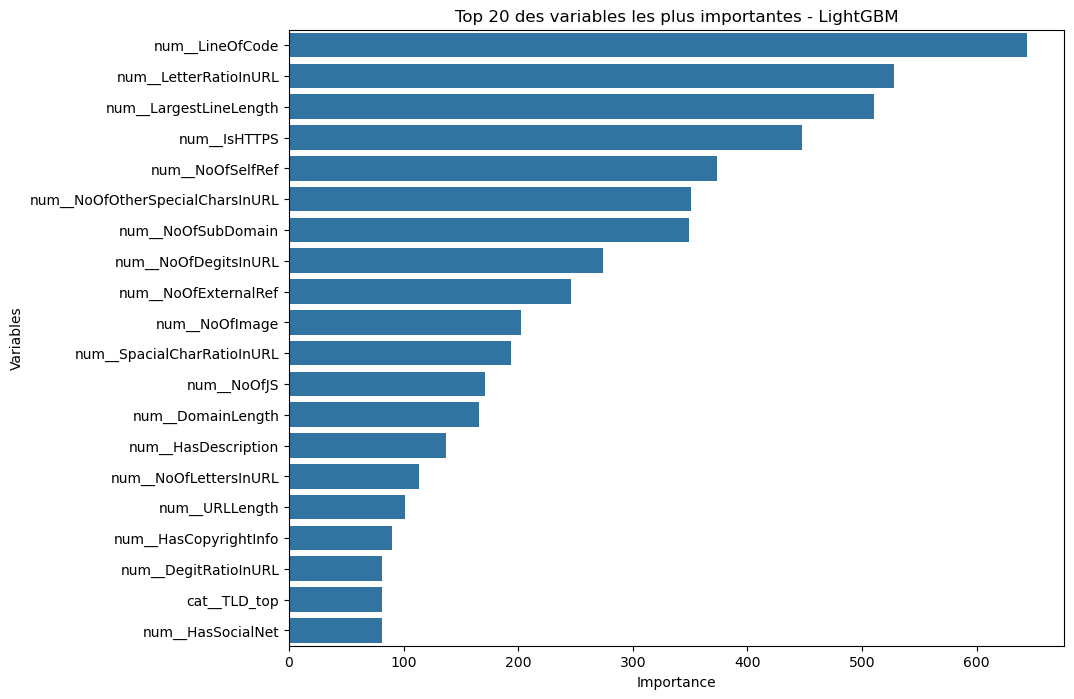

In [16]:
top_n = 20
top_features = importance_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 20 des variables les plus importantes - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

# Model tuning

In [17]:
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 5, 10],
    "model__min_child_samples": [10, 20, 30],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=final_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_case4, y_case4, groups=groups_case4)

print("Best params :", random_search.best_params_)
print("Best F1 CV  :", random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 134850, number of negative: 100945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.070654 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4079
[LightGBM] [Info] Number of data points in the train set: 235795, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571895 -> initscore=0.289587
[LightGBM] [Info] Start training from score 0.289587
Best params : {'model__subsample': 0.8, 'model__num_leaves': 15, 'model__n_estimators': 200, 'model__min_child_samples': 30, 'model__max_depth': 10, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best F1 CV  : 0.9999592176497366


In [18]:
best_lgbm_model = random_search.best_estimator_

y_pred_tuned = best_lgbm_model.predict(X_test_case4)
y_prob_tuned = best_lgbm_model.predict_proba(X_test_case4)[:, 1]

print("===== LightGBM Tuné - Test strict =====")
print("Accuracy :", accuracy_score(y_test_case4, y_pred_tuned))
print("Precision:", precision_score(y_test_case4, y_pred_tuned))
print("Recall   :", recall_score(y_test_case4, y_pred_tuned))
print("F1-score :", f1_score(y_test_case4, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test_case4, y_prob_tuned))
print("PR-AUC   :", average_precision_score(y_test_case4, y_prob_tuned))

print("\n===== Classification Report =====")
print(classification_report(y_test_case4, y_pred_tuned))

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== LightGBM Tuné - Test strict =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0
PR-AUC   : 1.0

===== Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19798
           1       1.00      1.00      1.00     26923

    accuracy                           1.00     46721
   macro avg       1.00      1.00      1.00     46721
weighted avg       1.00      1.00      1.00     46721



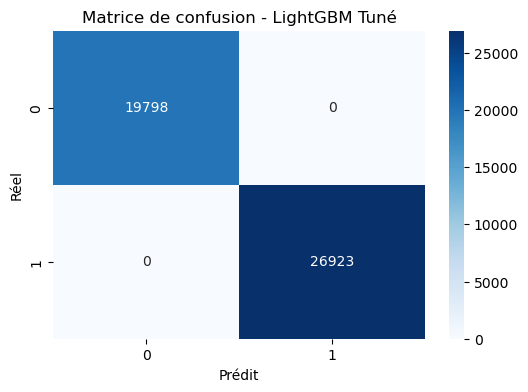

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_case4, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - LightGBM Tuné")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [20]:
# modèle de base déjà entraîné auparavant :
# final_model

y_pred_base = final_model.predict(X_test_case4)
y_prob_base = final_model.predict_proba(X_test_case4)[:, 1]

comparison_final = pd.DataFrame([
    {
        "Model": "LightGBM Base",
        "Accuracy": accuracy_score(y_test_case4, y_pred_base),
        "Precision": precision_score(y_test_case4, y_pred_base),
        "Recall": recall_score(y_test_case4, y_pred_base),
        "F1-score": f1_score(y_test_case4, y_pred_base),
        "ROC-AUC": roc_auc_score(y_test_case4, y_prob_base),
        "PR-AUC": average_precision_score(y_test_case4, y_prob_base),
    },
    {
        "Model": "LightGBM Tuné",
        "Accuracy": accuracy_score(y_test_case4, y_pred_tuned),
        "Precision": precision_score(y_test_case4, y_pred_tuned),
        "Recall": recall_score(y_test_case4, y_pred_tuned),
        "F1-score": f1_score(y_test_case4, y_pred_tuned),
        "ROC-AUC": roc_auc_score(y_test_case4, y_prob_tuned),
        "PR-AUC": average_precision_score(y_test_case4, y_prob_tuned),
    }
])

comparison_final

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,LightGBM Base,0.999936,0.999889,1.0,0.999944,1.0,1.0
1,LightGBM Tuné,1.000000,1.000000,1.0,1.000000,1.0,1.0


In [21]:
# récupérer les composants du pipeline tuné
lgbm_model_tuned = best_lgbm_model.named_steps["model"]
preprocessor_tuned = best_lgbm_model.named_steps["preprocessor"]

# noms des variables après preprocessing
feature_names_tuned = preprocessor_tuned.get_feature_names_out()

# importance
importance_df_tuned = pd.DataFrame({
    "Feature": feature_names_tuned,
    "Importance": lgbm_model_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df_tuned.head(20)

,Feature,Importance
18,num__LineOfCode,348
19,num__LargestLineLength,293
9,num__LetterRatioInURL,252
17,num__IsHTTPS,235
4,num__NoOfSubDomain,181
41,num__NoOfSelfRef,175
15,num__NoOfOtherSpecialCharsInURL,168
10,num__NoOfDegitsInURL,149
43,num__NoOfExternalRef,110
38,num__NoOfImage,106


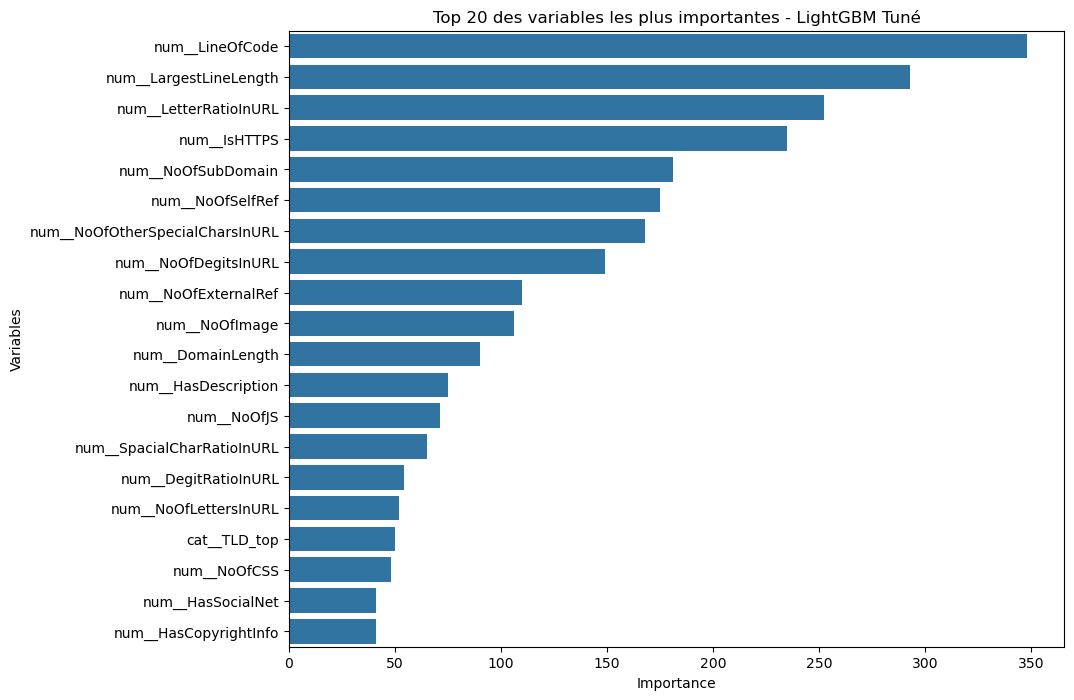

In [22]:
top_features_tuned = importance_df_tuned.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features_tuned, x="Importance", y="Feature")
plt.title("Top 20 des variables les plus importantes - LightGBM Tuné")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

# Le sauvegarde de modèle

In [24]:
import os
import json
import joblib

# créer un dossier pour les artefacts
os.makedirs("artifacts", exist_ok=True)

# 1) sauvegarder le pipeline complet (preprocessing + modèle LightGBM)
joblib.dump(best_lgbm_model, "artifacts/phishing_model.joblib")

# 2) sauvegarder la liste des features d'entrée
input_features = X_case4.columns.tolist()
joblib.dump(input_features, "artifacts/input_features.joblib")

# 3) sauvegarder des métadonnées utiles
metadata = {
    "model_name": "LightGBM",
    "target_column": TARGET_COL,
    "n_input_features": len(input_features),
    "input_features": input_features,
    "best_params": random_search.best_params_
}

with open("artifacts/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("Sauvegarde terminée avec succès.")
print("Fichiers créés :")
print("- artifacts/phishing_model.joblib")
print("- artifacts/input_features.joblib")
print("- artifacts/metadata.json")

Sauvegarde terminée avec succès.
Fichiers créés :
- artifacts/phishing_model.joblib
- artifacts/input_features.joblib
- artifacts/metadata.json


In [25]:
loaded_model = joblib.load("artifacts/phishing_model.joblib")
loaded_features = joblib.load("artifacts/input_features.joblib")

with open("artifacts/metadata.json", "r", encoding="utf-8") as f:
    loaded_metadata = json.load(f)

print("Rechargement réussi.")
print("Nom du modèle :", loaded_metadata["model_name"])
print("Nombre de features :", len(loaded_features))
print("Premières features :", loaded_features[:5])

Rechargement réussi.
Nom du modèle : LightGBM
Nombre de features : 45
Premières features : ['URLLength', 'DomainLength', 'IsDomainIP', 'TLD', 'TLDLength']
